# Visualización y Dashboard

En este notebook, nos conectaremos al Data Warehouse local (`olist_warehouse.db`).
 El objetivo es utilizar **SQL** y **Python (Seaborn/Matplotlib)** para poder responde a las preguntas estratégicas del negocio.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")

# Conectar a la base de datos
db_path = r"C:\Users\SAMY10\Documents\Olist\datos\db\olist_warehouse.db" 
conn = sqlite3.connect(db_path)

print("Conectado al Data Warehouse exitosamente.")

Conectado al Data Warehouse exitosamente.


# Q1: ¿Cuál es el volumen total de transacciones/registros por mes? ¿Hay estacionalidad?
En esta parte se identifica la estacionalidad y el comportamiento de las ventas a lo largo del tiempo. Filtramos los pedidos con estado **canceled** para analizar únicamente la intención de compra real y exitosa.

In [ ]:
# Consulta SQL: Agrupamos por año-mes y contamos los IDs unicos
query_q1 = """
SELECT 
    strftime('%Y-%m', order_purchase_timestamp) AS mes_anio,
    COUNT(order_id) AS total_transacciones
FROM fact_orders
WHERE order_status != 'canceled'
GROUP BY mes_anio
ORDER BY mes_anio;
"""
df_q1 = pd.read_sql_query(query_q1, conn)

# Eliminar el primer y último mes si están incompletos
df_q1 = df_q1.iloc[1:-1]

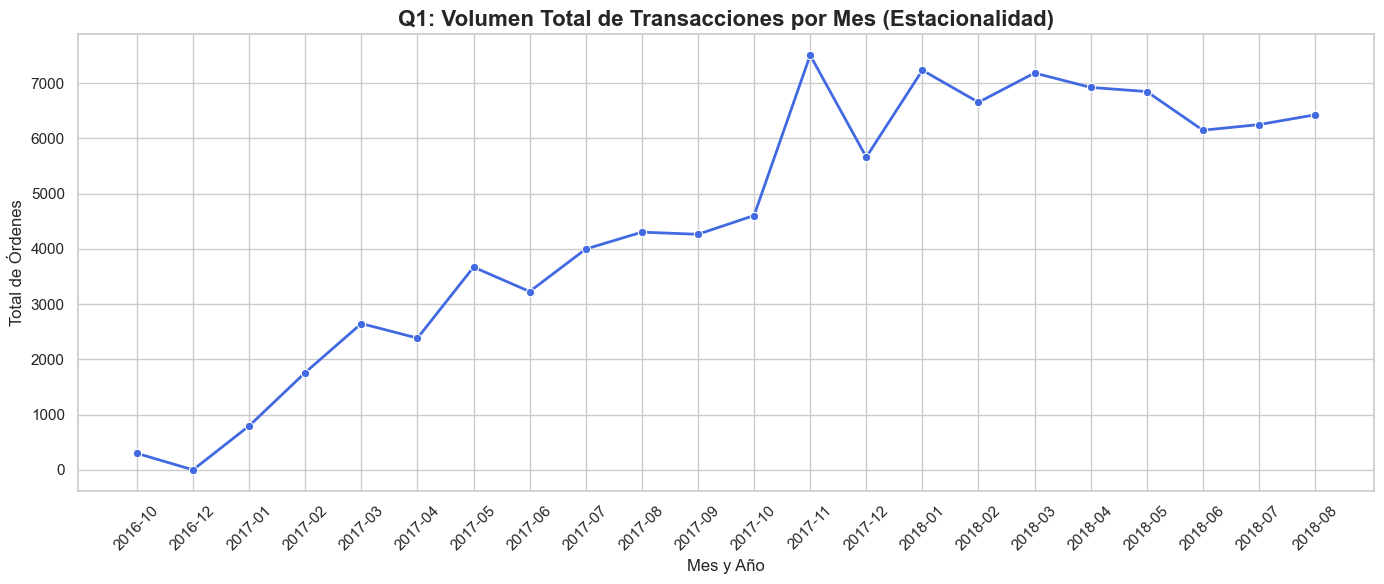

In [ ]:
# Visualizacion
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_q1, x='mes_anio', y='total_transacciones', marker='o', color='royalblue', linewidth=2)

plt.title('Q1: Volumen Total de Transacciones por Mes (Estacionalidad)', fontsize=16, fontweight='bold')
plt.xlabel('Mes y Año', fontsize=12)
plt.ylabel('Total de Órdenes', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusión (Q1):
* **Crecimiento sostenido:** Se observa una clara tendencia al alza en el volumen de ventas desde principios de 2017 hasta mediados de 2018, lo que indica un negocio en fase de expansión.
* **Estacionalidad fuerte (Black Friday):** El pico masivo de transacciones en **noviembre de 2017** resalta la enorme importancia del *Black Friday* en el e-commerce brasileño. La infraestructura de servidores y logística debe prepararse anualmente para este evento.


# Q2: ¿Cuáles son los 10 clientes, productos o categorías con mayor valor generado?
 En esta parte Descubriremos qué categorías de productos traen más ingresos a la empresa. Para esto, sumamos el precio de los ítems vendidos.

In [ ]:
# Consulta SQL: Unimos ventas con productos y categorias para tener el nombre en ingles
query_q2 = """
SELECT 
    c.product_category_name_english AS categoria,
    SUM(i.price) AS ingresos_totales
FROM fact_order_items i
JOIN dim_products p ON i.product_id = p.product_id
LEFT JOIN dim_categories c ON p.product_category_name = c.product_category_name
WHERE categoria IS NOT NULL
GROUP BY categoria
ORDER BY ingresos_totales DESC
LIMIT 10;
"""
df_q2 = pd.read_sql_query(query_q2, conn)

C:\Users\SAMY10\AppData\Local\Temp\ipykernel_18068\2958323572.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_q2, x='ingresos_totales', y='categoria', palette='viridis')


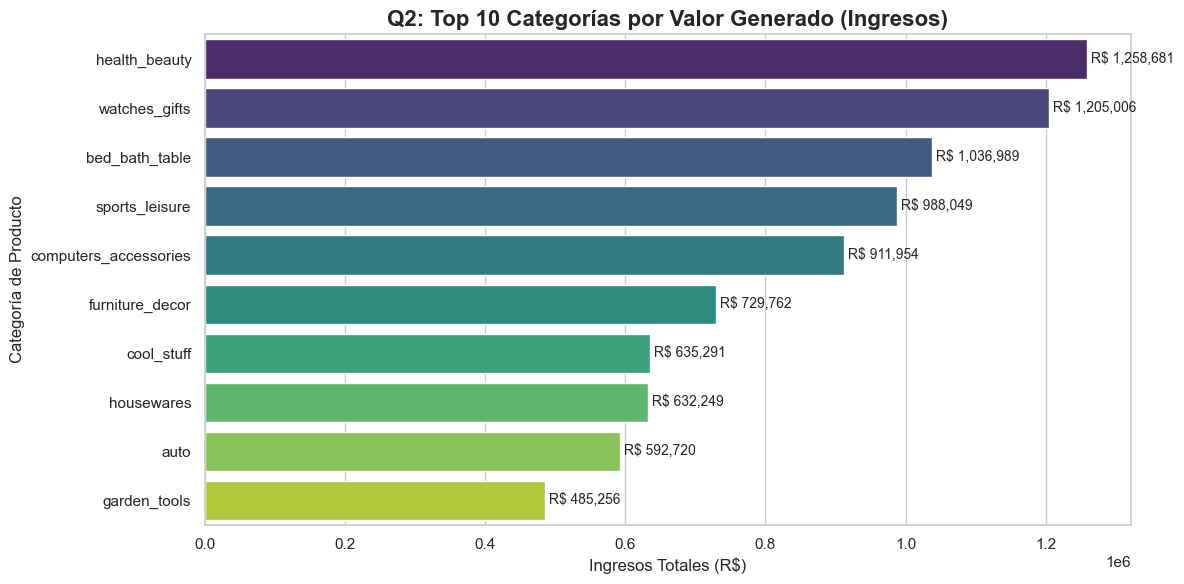

In [ ]:
# Visualización: Usamos un grafico de barras horizontales
plt.figure(figsize=(12, 6))
sns.barplot(data=df_q2, x='ingresos_totales', y='categoria', palette='viridis')

plt.title('Q2: Top 10 Categorías por Valor Generado (Ingresos)', fontsize=16, fontweight='bold')
plt.xlabel('Ingresos Totales (R$)', fontsize=12)
plt.ylabel('Categoría de Producto', fontsize=12)

# Agregar las etiquetas de datos en las barras
for index, value in enumerate(df_q2['ingresos_totales']):
    plt.text(value, index, f' R$ {value:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Conclusión (Q2):
*  Aunque categorías de ticket bajo como artículos de hogar (bed_bath_table) se venden en mucha cantidad, las categorías de **Salud y Belleza** (health_beauty) y **Relojes/Regalos** (watches_gifts) son los  mayores montos de ingreso para la empresa.
* **Sugerencia:** El equipo de marketing debería enfocar sus campañas de anuncios pagados en estas categorías top, ya que ofrecen el mayor retorno de inversión por transacción.

# Q3: ¿Cuál es el tiempo promedio entre eventos clave del flujo?
En esta parte calcularemos la diferencia en días entre la compra **order_purchase_timestamp** y la entrega real al cliente **order_delivered_customer_timestamp**. Mostraremos la distribución de estos tiempos para entender no solo el promedio, sino tambien los pedidos que tardan demasiado.

In [ ]:
# Consulta SQL: Usamos julianday() en SQLite para restar fechas y obtener la diferencia en dias
query_q3 = """
SELECT 
    (julianday(order_delivered_customer_timestamp) - julianday(order_purchase_timestamp)) AS dias_entrega
FROM fact_orders
WHERE order_delivered_customer_timestamp IS NOT NULL
  AND order_status = 'delivered';
"""
df_q3 = pd.read_sql_query(query_q3, conn)

# Calculamos el promedio para mostrarlo en el gráfico
tiempo_promedio = df_q3['dias_entrega'].mean()
mediana_entrega = df_q3['dias_entrega'].median()

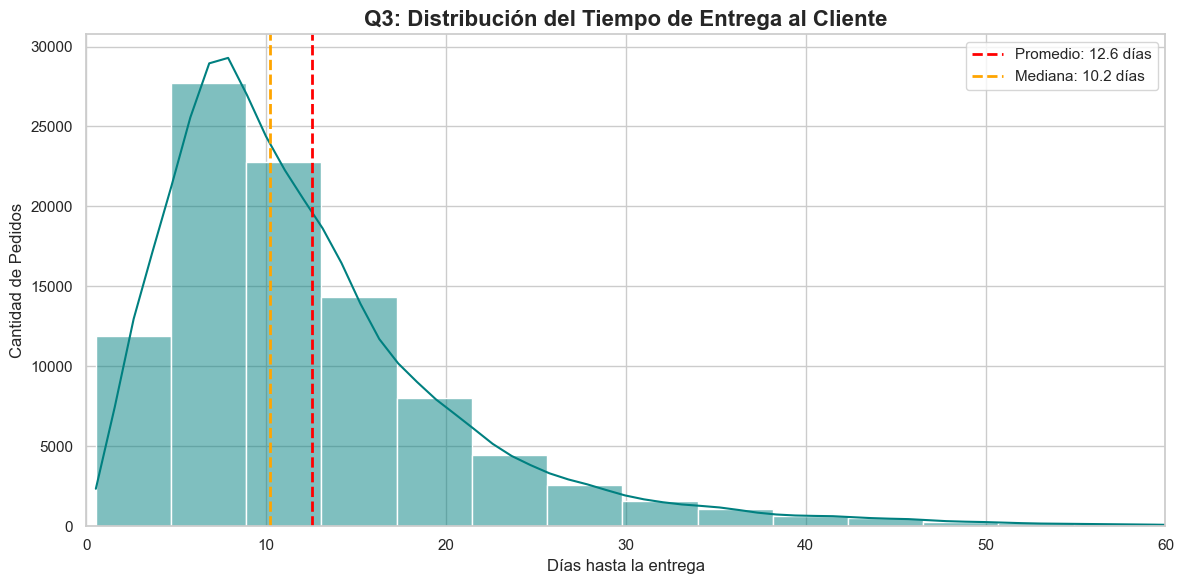

In [ ]:
# Visualización: Histograma para ver la distribucion de los dias
plt.figure(figsize=(12, 6))
sns.histplot(data=df_q3, x='dias_entrega', bins=50, color='teal', kde=True)

# Promedio y la Mediana
plt.axvline(tiempo_promedio, color='red', linestyle='dashed', linewidth=2, label=f'Promedio: {tiempo_promedio:.1f} días')
plt.axvline(mediana_entrega, color='orange', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_entrega:.1f} días')

plt.title('Q3: Distribución del Tiempo de Entrega al Cliente', fontsize=16, fontweight='bold')
plt.xlabel('Días hasta la entrega', fontsize=12)
plt.ylabel('Cantidad de Pedidos', fontsize=12)
# Limitamos el eje X a 60 dias para no ver el ruido de casos extremos(outliers)
plt.xlim(0, 60) 
plt.legend()
plt.tight_layout()
plt.show()

## Conclusión (Q3):
* La mediana de entrega ronda los **10 días**, lo cual es el estándar para la mayoría de los clientes. Sin embargo, el promedio es de **12 días** , este es más alto debido a un sesgo a la derecha.
* **El problema de los outliers:** Existen pedidos que tardan 30, 40 o hasta más de 50 días en llegar. Esta variabilidad extrema es peligrosa para la reputación de la marca. Es vital investigar si estos retrasos están asociados a transportistas específicos o a regiones remotas.

## Q4: ¿Qué porcentaje de registros tiene algún tipo de incidencia o resultado negativo?
Para entender la tasa de insatisfacción. Definiremos una "Incidencia" si ocurre alguna de estas dos cosas:
1. El pedido fue **Cancelado**.
2. El cliente dejó una **Mala Calificación** (1 o 2 estrellas).

In [ ]:
# Consulta SQL: Usamos CASE WHEN para clasificar el estado de cada pedido dependiendo de las órdenes y reseñas
query_q4 = """
SELECT 
    CASE
        WHEN o.order_status = 'canceled' THEN 'Cancelados'
        WHEN r.review_score <= 2 THEN 'Mala Calificación (1-2)'
        ELSE 'Sin Incidencias (Exitosos)'
    END AS tipo_incidencia,
    COUNT(DISTINCT o.order_id) AS total_pedidos
FROM fact_orders o
LEFT JOIN fact_reviews r ON o.order_id = r.order_id
GROUP BY tipo_incidencia;
"""
df_q4 = pd.read_sql_query(query_q4, conn)

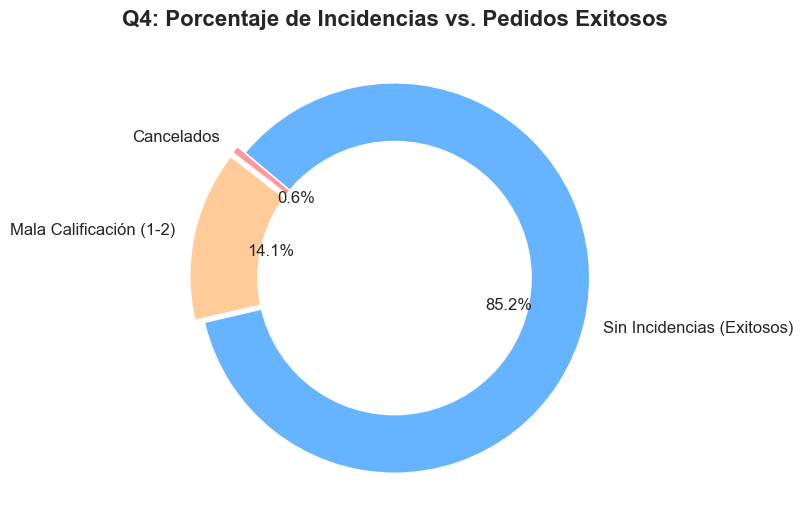

In [ ]:
# Visualización: Grafico de Dona para mostrar porcentajes 
plt.figure(figsize=(8, 8))
colores = ['#ff9999', '#ffcc99', '#66b3ff'] # Rojo pastel, Naranja pastel, Azul pastel
explode = (0.05, 0.05, 0) # Separa un poco

plt.pie(df_q4['total_pedidos'], labels=df_q4['tipo_incidencia'], autopct='%1.1f%%', 
        startangle=140, colors=colores, explode=explode, textprops={'fontsize': 12})

# Dibujar el círculo blanco en el centro
centro_circulo = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

plt.title('Q4: Porcentaje de Incidencias vs. Pedidos Exitosos', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

##  Conclusión (Q4):
* La gran mayoría de los pedidos (aprox. 84%) fluyen sin problemas y no generan rechazo, lo cual es positivo. Las cancelaciones puras son muy pocos (alrededor del 1%).
* El porcentaje de malas calificaciones (1 o 2 estrellas) ronda el 14-15%. Observando esta información con el gráfico anterior (Q3), es altamente probable que la principal causa de esta insatisfacción sean los tiempos de entrega prolongados. Reducir los tiempos de envío mejorará directamente esta métrica.

# Q5 (Pregunta Libre): ¿Qué estados de Brasil pagan los fletes más caros?
En esta parte se identificará los costos logísticos por región geográfica,ya que un flete muy alto en ciertos estados puede ser un cuello de botella para las ventas, lo que indicaría la necesidad de abrir nuevos centros de distribución o renegociar con transportistas locales.

In [ ]:
# Consulta SQL: Unimos items , ordenes , clientes para llegar al estado (customer_state)
query_q5 = """
SELECT 
    c.customer_state AS estado,
    AVG(i.freight_value) AS flete_promedio
FROM fact_order_items i
JOIN fact_orders o ON i.order_id = o.order_id
JOIN dim_customers c ON o.customer_id = c.customer_id
GROUP BY estado
ORDER BY flete_promedio DESC;
"""
df_q5 = pd.read_sql_query(query_q5, conn)

C:\Users\SAMY10\AppData\Local\Temp\ipykernel_18068\125380169.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_q5, x='estado', y='flete_promedio', palette='coolwarm_r')


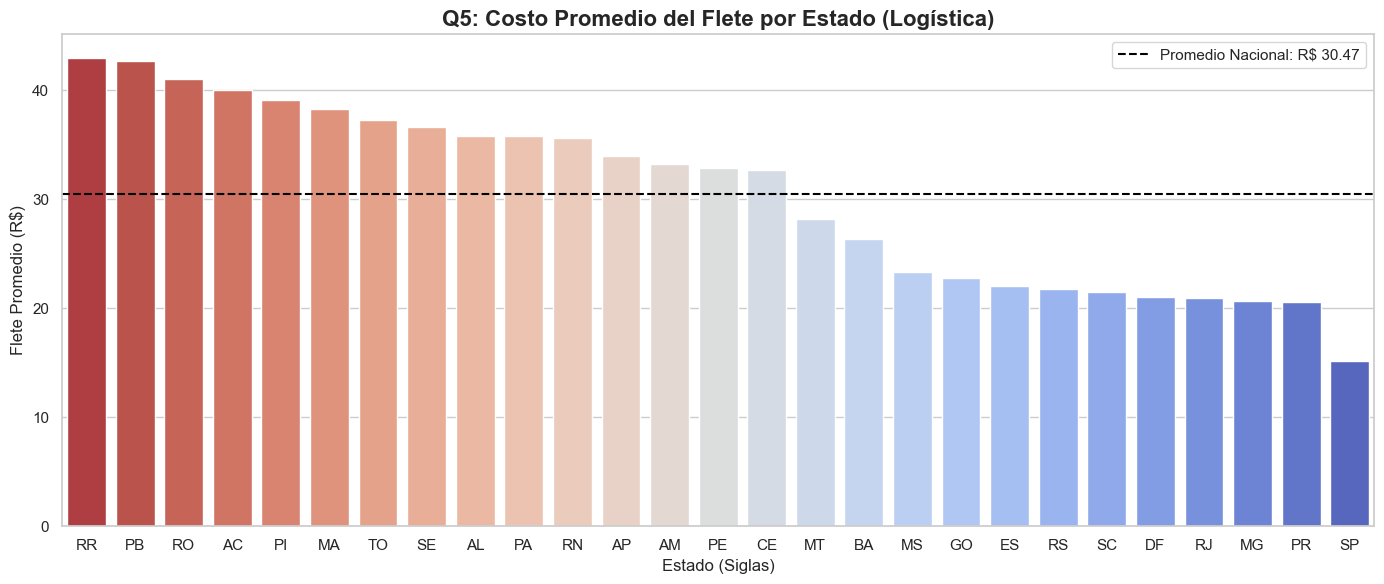

In [ ]:
# Visualización: Gráfico de barras
plt.figure(figsize=(14, 6))
# Usamos un mapa de color rojo/naranja para los mas caros y verde/azul para los mas baratos
sns.barplot(data=df_q5, x='estado', y='flete_promedio', palette='coolwarm_r')

# Linea del promedio nacional para tener una referencia
promedio_nacional = df_q5['flete_promedio'].mean()
plt.axhline(promedio_nacional, color='black', linestyle='--', linewidth=1.5, label=f'Promedio Nacional: R$ {promedio_nacional:.2f}')

plt.title('Q5: Costo Promedio del Flete por Estado (Logística)', fontsize=16, fontweight='bold')
plt.xlabel('Estado (Siglas)', fontsize=12)
plt.ylabel('Flete Promedio (R$)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

##  Conclusión (Q5):
* **Desigualdad geográfica:** Los estados del Norte y Noreste de Brasil (como **Roraima - RR, Paraiba - PB y Acre - AC**) pagan los costos de envío más altos de todo el país, superando drásticamente el promedio nacional.
* **Impacto en el negocio:** Como podemos observar, Sao Paulo (SP), donde se concentra la mayor parte de la industria, tiene el flete más barato. El alto costo logístico en las regiones remotas seguramente genera una alta tasa de carritos abandonados. 

Por lo tanto la empresa debería evaluar la apertura de centros de distribución regionales en el Norte/Noreste o negociar mejores tarifas con nuevos socios para así garantizar el acceso a sus productos.